# Spotify Hit Predictor - Popularity Tier Classification Model


## Phase 1 - Feature Engineering & Data Preprocessing


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\DELL\Desktop\what-makes-a-hit\spotify_deduplicated.csv")

In [3]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_tier,is_dead_track
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,Hit,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,Mid,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,Mid,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,Hit,0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,Viral,0


In [4]:
features = ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 'track_genre']
x = df[features].copy()
y_raw = df ['popularity']

In [5]:
le = LabelEncoder()
x['track_genre'] = le.fit_transform(x['track_genre'])

bins = [-1, 19, 49, 79, 100]
labels = ['Flop', 'Mid', 'Hit', 'Viral']
y = pd.cut(y_raw, bins=bins, labels=labels)

In [6]:
print('New Class Distribution:')
print(y.value_counts())

New Class Distribution:
popularity
Mid      43477
Hit      18841
Flop     17541
Viral      539
Name: count, dtype: int64


**Phase 2** - Handling Imbalance and Splitting Data

In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Resampled Training Class Distribution:')
print(pd.Series(y_train_resampled).value_counts())

Resampled Training Class Distribution:
popularity
Flop     34781
Mid      34781
Hit      34781
Viral    34781
Name: count, dtype: int64


**Phase 3 - Selecting and Training the Model**

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)

In [10]:
model.fit(X_train_resampled, y_train_resampled)
print("Training the model...this may take a moment...")

Training the model...this may take a moment...


In [11]:
y_pred = model.predict(X_test)
print("\nModel Evaluation Report:")
print(classification_report(y_test, y_pred))


Model Evaluation Report:
              precision    recall  f1-score   support

        Flop       0.57      0.56      0.56      3508
         Hit       0.47      0.51      0.49      3768
         Mid       0.72      0.68      0.70      8696
       Viral       0.09      0.23      0.13       108

    accuracy                           0.61     16080
   macro avg       0.46      0.49      0.47     16080
weighted avg       0.62      0.61      0.61     16080



In [12]:
df['explicit_genre'] = df['track_genre'] + '_' + df['explicit'].map({True: 'explicit', False: 'clean'})

In [13]:
print(df['explicit_genre'].value_counts().head(10))

explicit_genre
study_clean            996
bluegrass_clean        973
cantopop_clean         953
disney_clean           951
new-age_clean          951
forro_clean            950
idm_clean              945
chicago-house_clean    939
afrobeat_clean         937
tango_clean            935
Name: count, dtype: int64


In [14]:
features = [
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'tempo',
    'track_genre',
    'explicit_genre',
    'is_dead_track'
]

x = df[features].copy()

In [15]:
df['is_dead_track'] = df['popularity'] == 0
x['is_dead_track'] = df['is_dead_track'].astype(int)

Re-training the Model

In [16]:
le_genre = LabelEncoder()
le_explicit_genre = LabelEncoder()

x = df[features].copy()
x['track_genre'] = le_genre.fit_transform(x['track_genre'])
x['explicit_genre'] = le_explicit_genre.fit_transform(x['explicit_genre'])

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("Balanced successfully with new features.")

Balanced successfully with new features.


In [19]:
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(x_train_resampled, y_train_resampled)

y_pred_v2 = model_v2.predict(x_test)
print("\nModel Evaluation Report with New Features:")
print(classification_report(y_test, y_pred_v2))




Model Evaluation Report with New Features:
              precision    recall  f1-score   support

        Flop       0.77      0.74      0.75      3508
         Hit       0.53      0.61      0.57      3768
         Mid       0.77      0.72      0.75      8696
       Viral       0.08      0.23      0.12       108

    accuracy                           0.70     16080
   macro avg       0.54      0.58      0.55     16080
weighted avg       0.71      0.70      0.70     16080



C:\Users\DELL\AppData\Local\Temp\ipykernel_27024\3844594271.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')


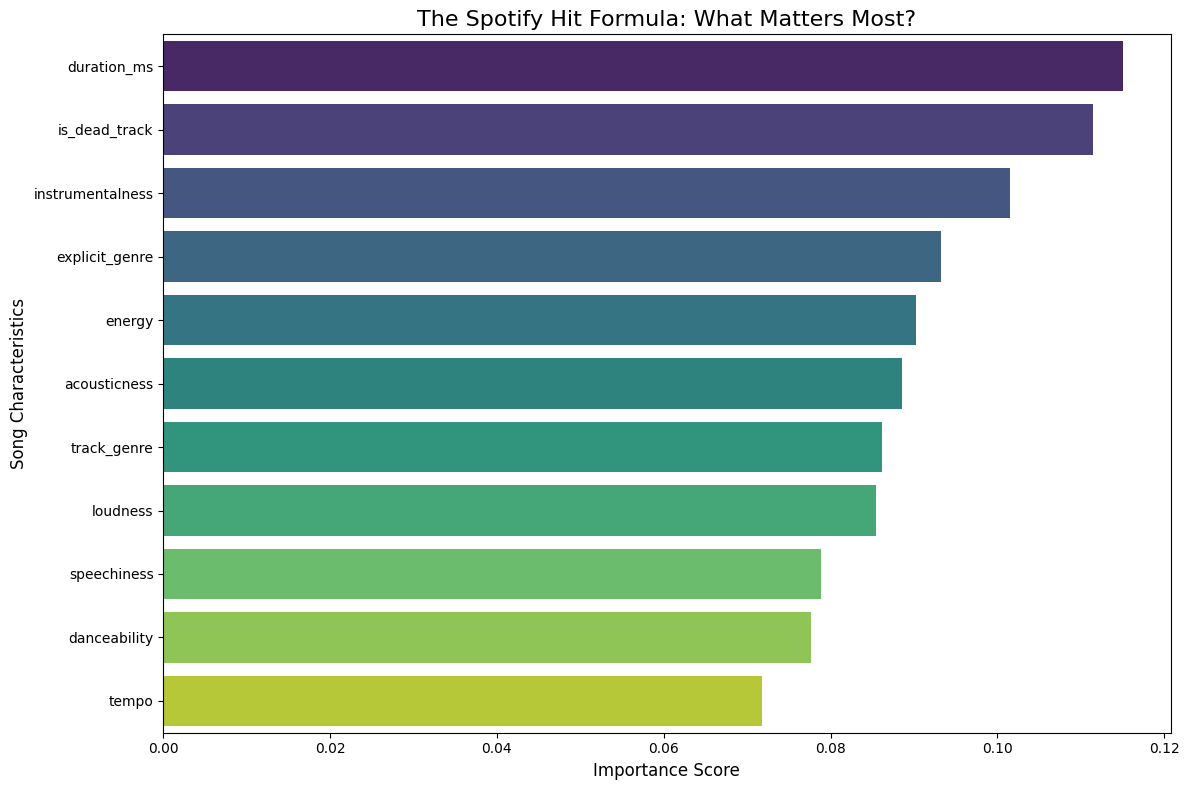

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = model_v2.feature_importances_
feature_names = x.columns
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')
plt.title('The Spotify Hit Formula: What Matters Most?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Song Characteristics', fontsize=12)

plt.tight_layout()
plt.show()

Prediction Function For The Model

In [23]:
def predict_song_status(duration_ms, genre, is_explicit,instrumentalness, energy, dead_track = 0):
   duration_ms = duration_ms * 60000

   expl_str = 'explicit' if is_explicit else 'clean'
   ex_genre_str = f"{genre}_{expl_str}"

   genre_encoded = le_genre.transform([genre])[0]
   ex_genre_encoded = le_explicit_genre.transform([ex_genre_str])[0]

   input_data = pd.DataFrame({
       'duration_ms': [duration_ms],
       'danceability': [0.5],
       'energy': [energy],
       'loudness': [-5.0],
       'speechiness': [0.05],
       'acousticness': [0.1],
       'instrumentalness': [instrumentalness],
       'tempo': [120],
       'track_genre': [genre_encoded],
       'explicit_genre': [ex_genre_encoded],
       'is_dead_track': [dead_track]
    })
   
   prediction = model_v2.predict(input_data)[0]
   return f"The model predicts this song will be a: {prediction}"

print(predict_song_status(duration_ms=3.5, genre='pop', is_explicit=False, instrumentalness=0.0, energy=0.8))

The model predicts this song will be a: Viral
